In [26]:
import os
import sys
import json
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../BACKEND"))

# Import functions directly from pipeline.py
from pipeline import load_api_key, pipeline

In [27]:
api_key = load_api_key()
# el = pipeline(api_key=api_key, platform='EUW1', player_name='401dmg', player_tag='6969', count=1, save=1) #H2P_Gucio
with open('data_full.json', encoding='utf-8') as f:
    data = json.load(f)
data.keys()

dict_keys(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19'])

Dropping unnecesarry columns with irrelevant data

In [28]:
players = []
for match in data.values():
    for player in match[0]['players']:
        players.append(player)
        
    df = pd.DataFrame(players)    
    df = df.drop(columns=['username', 'championImageLink', 'summonerLevel', 'teamId', 'goldEarned', 'needVisionPings', 'enemyVisionPings', 'allInPings', 'pushPings',
        'assistMePings', 'commandPings', 'dangerPings', 'enemyMissingPings', 'gameEndedInSurrender',
        'onMyWayPings', 'retreatPings', 'icon', 'caller', 'masteries'])
        
    df = df.set_index('puuid')

Handling nested json object

In [29]:
df["summoner_1"] = df["summoners"].str[0].str["name"]
df["summoner_2"] = df["summoners"].str[1].str["name"]
df = df.drop(columns=['summoners', 'runes', 'items', 'metadata'])

Splitting summoner spells 

In [31]:
summs_ohe = pd.get_dummies(df[["summoner_1", "summoner_2"]], dtype=int)

spell_to_columns = {}
for col in summs_ohe.columns:
    spell_name = col.replace("summoner_1_", "").replace("summoner_2_", "")
    spell_to_columns.setdefault(spell_name, []).append(col)

summoners_encoded = pd.DataFrame(
    {f"summoner_{spell}": summs_ohe[cols].max(axis=1) for spell, cols in spell_to_columns.items()},
    index=df.index,
    )

final_df = pd.concat([df, summoners_encoded], axis=1)

In [32]:
final_df = final_df.drop(columns=['summoner_1', 'summoner_2'])

In [33]:
final_df.head()

,teamPosition,championName,kills,deaths,assists,champLevel,KDA,killParticipation,skillshotsDodged,skillshotsHit,...,timeCCingOthers,totalTimeSpentDead,summoner_Barrier,summoner_Exhaust,summoner_Flash,summoner_Ghost,summoner_Heal,summoner_Ignite,summoner_Smite,summoner_Teleport
puuid,,,,,,,,,,,,,,,,,,,,,
hSLo-Luk0wAHoHECwm734pOI1lH_R1-JpM4vSZXXwdt-E7XSAF9KBnxojooKQwjrVbkrkplLwXuEIQ,TOP,Yasuo,12,8,14,19,3.25,43.33,78,21,...,39,274,0,1,1,0,0,0,0,0
vpLTCMGQaCfuPU-55xKLXhs093WH61jTwiGSnzeXUp_ZETmELx1ljSbHB40mJ-0U_ZNM0RmQk07cVw,JUNGLE,Kayn,20,3,15,18,11.67,58.33,224,0,...,14,61,0,0,1,0,0,0,1,0
xPHmu9CfosDOOBhLlOvh76dGqUoayK5i8oM_4agCMlruyHA_XldPeZhncEd87R3QCYhlHFQQwVAr6Q,MIDDLE,Aurora,21,4,14,18,8.75,58.33,71,23,...,15,215,0,0,1,0,0,0,0,1
4n-VCXRrPgh3wapPjiW7Jer_AJ5KzpQrhsr4h4vpOJOVemvW7rReFYxSEN7lYoDKtxQHO0DcyVNxMw,BOTTOM,Jhin,5,5,11,15,3.20,26.67,89,12,...,27,192,1,0,1,0,0,0,0,0
q3pPG3bpZ7YeqYG27fy24y4r05HT5Q3hXZDgvzreXpQiDDL1Gg0B-VcAS6KnLnIei-02Wwbe3jN55A,UTILITY,Blitzcrank,2,7,20,14,3.14,36.67,213,25,...,53,201,0,0,1,0,0,1,0,0


Spliting data into index table and statistics values table

In [34]:
index_table_df = final_df[["teamPosition", "championName"]].copy()
index_table_df.insert(0, "puuid", final_df.index)

numerical_stats_df = final_df.drop(columns=["teamPosition", "championName"])
numerical_stats_df['win'] = numerical_stats_df['win'].astype(int)
numerical_stats_df = numerical_stats_df.select_dtypes(include=["number"]).copy()

Normalization of values inside stats table. Min-max normalization to values $x \in [0, 1]$

In [35]:
# Min-max normalization to [0, 1]
normalized_stats_df = numerical_stats_df.copy()

for col in normalized_stats_df.columns:
    min_col_value = normalized_stats_df[col].min()
    max_col_value = normalized_stats_df[col].max()

    if max_col_value == min_col_value:
        normalized_stats_df[col] = 0.0
    else:
        normalized_stats_df[col] = (
            (normalized_stats_df[col] - min_col_value)
            / (max_col_value - min_col_value)
        )

Coefficent matrix is plotted to verify data connections.

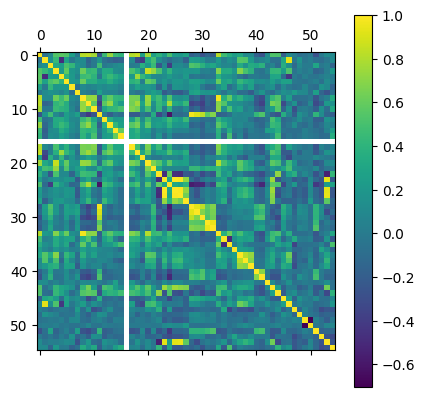

In [36]:
plt.matshow(normalized_stats_df.corr())
plt.colorbar()

In [45]:
normalized_stats_df.head()

,kills,deaths,assists,champLevel,KDA,killParticipation,skillshotsDodged,skillshotsHit,damagePerMinute,goldPerMinute,...,timeCCingOthers,totalTimeSpentDead,summoner_Barrier,summoner_Exhaust,summoner_Flash,summoner_Ghost,summoner_Heal,summoner_Ignite,summoner_Smite,summoner_Teleport
puuid,,,,,,,,,,,,,,,,,,,,,
hSLo-Luk0wAHoHECwm734pOI1lH_R1-JpM4vSZXXwdt-E7XSAF9KBnxojooKQwjrVbkrkplLwXuEIQ,0.48,0.5000,0.466667,0.947368,0.116071,0.566627,0.293233,0.148936,0.441310,0.428249,...,0.302326,0.498182,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
vpLTCMGQaCfuPU-55xKLXhs093WH61jTwiGSnzeXUp_ZETmELx1ljSbHB40mJ-0U_ZNM0RmQk07cVw,0.80,0.1875,0.500000,0.894737,0.416786,0.762783,0.842105,0.000000,0.602277,0.739865,...,0.108527,0.110909,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
xPHmu9CfosDOOBhLlOvh76dGqUoayK5i8oM_4agCMlruyHA_XldPeZhncEd87R3QCYhlHFQQwVAr6Q,0.84,0.2500,0.466667,0.894737,0.312500,0.762783,0.266917,0.163121,0.773372,0.643924,...,0.116279,0.390909,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4n-VCXRrPgh3wapPjiW7Jer_AJ5KzpQrhsr4h4vpOJOVemvW7rReFYxSEN7lYoDKtxQHO0DcyVNxMw,0.20,0.3125,0.366667,0.736842,0.114286,0.348764,0.334586,0.085106,0.172712,0.293607,...,0.209302,0.349091,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
q3pPG3bpZ7YeqYG27fy24y4r05HT5Q3hXZDgvzreXpQiDDL1Gg0B-VcAS6KnLnIei-02Wwbe3jN55A,0.08,0.4375,0.666667,0.684211,0.112143,0.479534,0.800752,0.177305,0.163790,0.120885,...,0.410853,0.365455,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


Association rules for the win attribute use a binary view of the normalized stats. In this notebook, trust is treated as confidence.

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Convert normalized values into presence/absence items for rule mining
# 'high_' means the normalized value is at least 0.5.
binary_stats_df = normalized_stats_df.drop(columns=['win']).ge(0.5)
binary_stats_df = binary_stats_df.rename(columns=lambda col: f'high_{col}')
binary_stats_df['win'] = normalized_stats_df['win'].ge(0.5)

frequent_itemsets = apriori(binary_stats_df, min_support=0.1, use_colnames=True)

if frequent_itemsets.shape[0] < 1:
    win_rules = pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'trust', 'lift'])
else:
    rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.6)
    win_rules = rules[rules['consequents'] == frozenset({'win'})].copy()
    win_rules['trust'] = win_rules['confidence']
    win_rules = win_rules.sort_values(['trust', 'support', 'lift'], ascending=False)

def itemset_to_text(itemset):
    readable_items = []
    for item in sorted(itemset):
        if item == 'win':
            readable_items.append('win')
        elif item.startswith('high_'):
            readable_items.append(f'high {item[5:]}')
        else:
            readable_items.append(item)
    return ' and '.join(readable_items)

win_rules_display = win_rules.assign(
    antecedents=win_rules['antecedents'].map(itemset_to_text),
    consequents=win_rules['consequents'].map(itemset_to_text),
    support=win_rules['support'].round(3),
    trust=win_rules['trust'].round(3),
    lift=win_rules['lift'].round(3),
)

win_rules_display[['antecedents', 'consequents', 'support', 'trust', 'lift']].head(10)

,antecedents,consequents,support,trust,lift
1936,"frozenset({goldSpent, damageDealtToTurrets})",frozenset({win}),0.100,0.952381,1.904762
6230,"frozenset({goldSpent, champLevel, damageDealtT...",frozenset({win}),0.100,0.952381,1.904762
10304,"frozenset({totalMinionsKilled, goldSpent, dama...",frozenset({win}),0.100,0.952381,1.904762
10650,"frozenset({summoner_Flash, goldSpent, damageDe...",frozenset({win}),0.100,0.952381,1.904762
23501,"frozenset({totalMinionsKilled, goldSpent, cham...",frozenset({win}),0.100,0.952381,1.904762
24246,"frozenset({summoner_Flash, goldSpent, champLev...",frozenset({win}),0.100,0.952381,1.904762
32586,"frozenset({summoner_Flash, totalMinionsKilled,...",frozenset({win}),0.100,0.952381,1.904762
56609,"frozenset({summoner_Flash, champLevel, damageD...",frozenset({win}),0.100,0.952381,1.904762
399,"frozenset({kills, cs_min})",frozenset({win}),0.125,0.925926,1.851852
2753,"frozenset({kills, champLevel, cs_min})",frozenset({win}),0.125,0.925926,1.851852
